# E5 Dataset-Induced Biomedical Simplification Graph


## Imports and Paths

In [ ]:
from __future__ import annotations

import pickle
import re
from collections import Counter, defaultdict
from difflib import SequenceMatcher
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TRAIN_PATH = PROJECT_ROOT / "data" / "sentence_no_context" / "train_clean.csv"
KG_DIR = PROJECT_ROOT / "data" / "knowledge_graph"
FIGURES_DIR = PROJECT_ROOT / "figures"

NODES_PATH = KG_DIR / "nodes.csv"
EDGES_PATH = KG_DIR / "edges.csv"
RAW_EDGES_PATH = KG_DIR / "edges_raw_candidates.csv"
EXPANDED_EDGES_PATH = KG_DIR / "edges_expanded.csv"
SCORING_REPORT_PATH = KG_DIR / "edge_scoring_report.csv"
GPICKLE_PATH = KG_DIR / "biomedical_knowledge_graph.gpickle"
GRAPHML_PATH = KG_DIR / "biomedical_knowledge_graph.graphml"
TOP_RELATIONS_FIGURE_PATH = FIGURES_DIR / "knowledge_graph_top_relations.png"

KG_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MIN_EDGE_FREQUENCY = 1
MIN_EDGE_QUALITY = 2.0
MAX_SPAN_TOKENS = 6
MAX_TARGETS_PER_SOURCE = 1

print(f"Project root: {PROJECT_ROOT}")
print(f"Training file: {TRAIN_PATH.relative_to(PROJECT_ROOT)}")
print(f"Knowledge graph directory: {KG_DIR.relative_to(PROJECT_ROOT)}")





## Load Training Data



In [13]:
if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Missing training data: {TRAIN_PATH}")

train_df = pd.read_csv(TRAIN_PATH)
required_columns = ["complex", "simple"]
missing_columns = [column for column in required_columns if column not in train_df.columns]
if missing_columns:
    raise ValueError(f"train_clean.csv is missing columns: {missing_columns}")

pairs_df = train_df[required_columns].copy()
pairs_df["complex"] = pairs_df["complex"].fillna("").astype(str).str.strip()
pairs_df["simple"] = pairs_df["simple"].fillna("").astype(str).str.strip()
pairs_df = pairs_df[pairs_df["complex"].ne("") & pairs_df["simple"].ne("")].reset_index(drop=True)
pairs_df["pair_index"] = pairs_df.index

print(f"Loaded training pairs: {len(pairs_df):,}")
display(pairs_df.head())

Loaded training pairs: 6,742


,complex,simple,pair_index
0,Three studies (146 participants) met our selec...,Three studies involving 146 participants were ...,0
1,The three studies assessed palliative care as ...,All three studies compared palliative care del...,1
2,One of the three studies included participants...,The third study (Ne-PAL) included participants...,2
3,The three included studies did not assess the ...,"The included studies did not assess fatigue, c...",3
4,We did not find any trial that compared differ...,We did not find studies that compared differen...,4


## Text Normalization and Tokenization

In [14]:
TOKEN_PATTERN = re.compile(r"[A-Za-z]+(?:[-'][A-Za-z]+)?|\d+(?:\.\d+)?%?")

STOPWORDS = {
    "a", "an", "the", "and", "or", "but", "of", "in", "on", "to", "for", "with", "without",
    "by", "from", "at", "as", "than", "then", "that", "this", "these", "those", "was", "were",
    "is", "are", "be", "been", "being", "had", "has", "have", "having", "did", "does", "do",
    "not", "no", "we", "our", "they", "their", "patients", "patient", "participants", "participant",
    "people", "person", "group", "groups", "study", "studies", "trial", "trials", "review",
    "evidence", "result", "results", "outcome", "outcomes",
}

GENERAL_WORDS = STOPWORDS | {
    "more", "less", "few", "fewer", "many", "most", "some", "any", "all", "may", "might", "can",
    "could", "would", "should", "showed", "found", "reported", "included", "compared", "received",
    "reduced", "increased", "improved", "different", "difference", "important", "small", "large",
    "required", "needed", "suggest", "suggested", "conclude", "concluded", "available", "current",
}

NON_TERM_SOURCE_TOKENS = GENERAL_WORDS | {
    "there", "here", "also", "however", "therefore", "thus", "overall", "probably", "possibly",
    "brief", "long", "short", "term", "follow-up", "using", "used", "use", "care", "usual",
    "identified", "identify", "assessed", "assess", "comparing", "compare", "versu", "versus",
    "further", "including", "include", "unable", "able", "significant", "supplemented", "supplement",
    "required", "require", "available", "observed", "evaluated", "evaluate", "provided", "provide",
    "receiving", "receive", "conducted", "conduct", "determine", "determined", "involving", "involved",
    "regarding", "remaining", "although", "appeared", "appear", "approximately", "event",
}

NON_TERM_TARGET_TOKENS = STOPWORDS | {
    "found", "compared", "compared to", "more", "such as", "not able", "clear", "needed",
    "containing", "included", "including", "reported", "showed", "seen", "planned",
    "who received", "carried out", "show", "involved", "about", "other", "however", "seemed",
    "there", "use", "place", "consider", "curtain", "controlled", "greater", "important",
}

DEMOGRAPHIC_OR_STUDY_POPULATION_TERMS = {
    "participant", "participants", "patient", "patients", "person", "people", "adult", "adults",
    "child", "children", "woman", "women", "man", "men", "mother", "mothers", "infant", "infants",
}

NON_BIOMEDICAL_SOURCE_TERMS = DEMOGRAPHIC_OR_STUDY_POPULATION_TERMS | {
    "comparison", "effectiveness", "clinical", "analogue", "approximately",
}

NON_TERM_SOURCE_PHRASES = {
    "there was", "there were", "we found", "we included", "we did", "we are", "it wa", "it is",
    "this review", "this study", "our review", "the review", "the study",
}


def normalize_text(text: str) -> str:
    text = text.lower()
    text = text.replace("–", "-").replace("—", "-")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize(text: str) -> list[str]:
    return [token.lower() for token in TOKEN_PATTERN.findall(normalize_text(text))]


def singularize_token(token: str) -> str:
    if len(token) > 4 and token.endswith("ies"):
        return token[:-3] + "y"
    # Keep biomedical singular endings intact, e.g. prophylaxis, sepsis, ductus.
    if token.endswith(("sis", "xis", "us")):
        return token
    if len(token) > 3 and token.endswith("s") and not token.endswith("ss"):
        return token[:-1]
    return token


def normalize_phrase(tokens: list[str]) -> str:
    normalized = [singularize_token(token.lower()) for token in tokens]
    return " ".join(normalized).strip()


def phrase_word_count(phrase: str) -> int:
    return len(phrase.split())

print(tokenize("Patients with hypertension received anticoagulants."))
print(normalize_phrase(tokenize("anticoagulants")))

['patients', 'with', 'hypertension', 'received', 'anticoagulants']
anticoagulant


## Alignment Heuristics



In [ ]:
def technical_score(phrase: str) -> float:
    tokens = phrase.split()
    if not tokens:
        return 0.0
    score = 0.0
    for token in tokens:
        if token in GENERAL_WORDS:
            score -= 0.5
        if len(token) >= 8:
            score += 0.8
        if any(part in token for part in [
            "itis", "osis", "emia", "pathy", "card", "renal", "pulmon", "thromb", "hyper", "hypo",
            "anti", "glyc", "myocard", "mortality", "morbidity", "neuro", "vascular", "carcin", "analgesi",
            "prophyl", "cortic", "gluco", "hep", "arter", "duct", "sepsis", "infection", "inflamm",
        ]):
            score += 1.4
        if "-" in token:
            score += 0.3
    if len(tokens) == 1:
        score += 0.3
    if len(tokens) >= 2:
        score += 0.4
    return score


def simple_score(phrase: str) -> float:
    tokens = phrase.split()
    if not tokens:
        return 0.0
    score = 0.0
    for token in tokens:
        if token in GENERAL_WORDS:
            score += 0.2
        if len(token) <= 7:
            score += 0.25
    if len(tokens) > 1:
        score += 0.7
    return score


BIOMEDICAL_MARKERS = {
    "mortality", "morbidity", "adverse", "event", "incidence", "prevalence", "pulmonary",
    "corticosteroid", "analgesia", "cerclage", "arteriosu", "arteriosus", "ductu", "ductus", "lmwh", "bmmnc",
    "diabetic", "diabetes", "neuropathy", "radiotherapy", "antibiotic", "clinical", "renal", "cardiac",
    "myocardial", "hypothyroidism", "hyperthyroidism", "fracture", "steroid", "cancer",
    "exacerbation", "glucose", "antibody", "nephrectomy", "neurodevelopmental", "progestin",
    "progesterone", "prophylaxi", "prophylaxis", "rhtsh", "transfusion", "thyrotropin", "hypertension",
    "anticoagulant", "inflammation", "infection", "sepsis", "asthma", "placebo", "embolism", "thrombosis",
    "angioplasty", "infarction", "neonatal", "maternal", "caesarean", "cesarean", "opioid", "epidural",
    "chemotherapy", "rehabilitation", "ventilation", "pneumonia", "depression", "anxiety", "cognitive",
}

STATISTICAL_TERM_MARKERS = {
    "proportion", "rate", "ratio", "risk", "efficacy", "effectiveness", "sample size",
    "certainty", "low-certainty", "high-certainty", "outcome", "response", "comparison",
    "confidence interval", "relative risk", "odds ratio", "hazard ratio", "statistically", "heterogeneous",
}

DOMAIN_TERM_EXACT = {
    "intervention", "interventions", "proportion", "incidence", "prevalence", "mortality", "morbidity",
    "adverse event", "adverse events", "sample size", "clinical response", "patent ductu arteriosu",
    "myocardial infarction", "confidence interval", "relative risk", "quality of life", "clinical pregnancy",
}

GENERIC_SOURCE_TERMS = {
    "risk", "rate", "effect", "effects", "quality", "delivery", "comparison", "comparisons",
    "clinical", "outcome", "outcomes", "result", "results", "difference", "evidence", "review",
    "study", "studies", "trial", "trials", "group", "groups", "participant", "participants",
    "adverse", "placebo", "statistically", "reduction", "ratio", "prevention", "neonatal",
    "maternal", "antibiotic", "myocardial", "infarction", "prophylactic", "preventing",
}

ALLOWED_SINGLE_SOURCE_TERMS = {
    "mortality", "morbidity", "incidence", "prevalence", "proportion", "efficacy",
    "analgesia", "analgesic", "bmmnc", "caesarean", "cardiac", "cerclage", "corticosteroid",
    "exacerbation", "glucose", "hypertension", "lmwh", "nephrectomy", "progestin",
    "prophylaxi", "pulmonary", "rhtsh", "ventilation", "antiplatelet", "antihypertensive",
    "antimicrobial", "antipsychotic", "antiseptic", "antithyroid", "comorbidity", "opioid",
}

NOISY_SOURCE_TOKENS = {
    "eligible", "uncontrolled", "adequately", "powered", "randomised", "randomized", "actually",
    "attending", "comparison", "alternative", "semi-recumbent", "children", "hospital", "assessed",
    "non-severe", "clinically", "arterial", "certainty", "statistically", "reduction", "prevention",
}

GENERIC_TARGET_TERMS = {
    "number", "numbers", "effect", "effects", "method", "methods", "there", "other", "different",
    "used", "found", "included", "reported", "clear", "needed", "treatment", "treatments",
}

BAD_TARGET_PATTERNS = [
    r"\buseds\b",
    r"\bdissimilars\b",
    r"\bpreventions\b",
    r"\bdebilitating side\b",
    r"\blimited number\b",
    r"\bthe number\b",
    r"\bthere\b",
    r"\blarge loop excision\b",
    r"\d",
    r"\bbaby\b",
    r"\bcost\b",
    r"\bmeasure\b",
    r"\bassessed\b",
    r"\boccurred\b",
    r"\bfollowing finding\b",
    r"\bafter intervention\b",
    r"\bamong survivor\b",
    r"\bdoctor performing\b",
    r"\btherefore beneficial\b",
    r"\bimportant long-term clinical\b",
    r"\bimproved over time\b",
    r"\bduring pregnancy compared\b",
    r"\bdespite available data\b",
    r"\btechnique using two plate\b",
    r"\bcurrent glucose lowering treatment\b",
    r"\bhigh quality\b",
    r"\blow quality\b",
    r"\bsteroid dose\b",
]

READABLE_TARGET_HINTS = {
    "death", "side effect", "side effects", "heart attack", "lung", "blood sugar", "steroid", "steroids",
    "illness", "ill health", "pain relief", "frequency", "percentage", "low-quality", "high-quality", "heart", "attack",
    "attacks", "surgery", "hormone", "high blood pressure", "blood thinner", "blood thinners", "swelling",
    "infection", "infections", "getting pregnant", "quality of life", "other conditions", "new case", "birth",
    "cell therapy", "stitch", "other condition", "prevention", "ventilator", "harm", "side-effect",
}

CONTEXTUAL_TARGET_TOKENS = {
    "also", "another", "available", "brain", "case", "certainty", "clinical", "compared",
    "comparison", "current", "data", "delivery", "develop", "dose", "during", "epidural",
    "forcep", "function", "implementation", "important", "imprecise", "improved", "injectable",
    "level", "long-term", "method", "number", "over", "phlegm", "plate", "primary",
    "quality", "regarding", "remain", "schedule", "showed", "sight", "strategy", "suppression",
    "surgical", "target", "technique", "term", "time", "total", "treatment", "undergoing",
    "used", "versu", "weak",
}

BAD_SOURCE_PHRASE_PATTERNS = [
    r"\bcomparative effectiveness\b",
    r"\bexamining\b",
    r"\bsecondary clinical\b",
    r"\bsustained virological response\b",
    r"\bwomen who took placebo\b",
    r"\bnon-measle pneumonia\b",
    r"\bhigh mortality\b",
    r"\blong antibiotic\b",
]


def has_biomedical_marker(tokens: list[str]) -> bool:
    joined = " ".join(tokens)
    return any(marker in joined for marker in BIOMEDICAL_MARKERS)


def marker_matches_phrase(markers: set[str], phrase: str, tokens: list[str], allow_substring: bool = False) -> bool:
    for marker in markers:
        marker_tokens = marker.split()
        if len(marker_tokens) > 1 and marker in phrase:
            return True
        if len(marker_tokens) == 1:
            if marker in tokens:
                return True
            if allow_substring and any(marker in token for token in tokens):
                return True
    return False


def domain_term_score(phrase: str) -> float:
    tokens = phrase.split()
    joined = " ".join(tokens)
    score = 0.0
    if joined in DOMAIN_TERM_EXACT:
        score += 3.0
    if marker_matches_phrase(BIOMEDICAL_MARKERS, joined, tokens, allow_substring=True):
        score += 2.0
    if marker_matches_phrase(STATISTICAL_TERM_MARKERS, joined, tokens, allow_substring=False):
        score += 1.2
    if len(tokens) == 1 and len(tokens[0]) <= 7 and re.search(r"[a-z]*[bcdfghjklmnpqrstvwxyz]{3,}[a-z]*", tokens[0]):
        score += 0.9
    if any(len(token) >= 10 for token in tokens):
        score += 0.6
    if any(token in NON_TERM_SOURCE_TOKENS for token in tokens):
        score -= 0.8
    if any(token in STOPWORDS for token in tokens) and joined not in DOMAIN_TERM_EXACT:
        score -= 2.0
    if joined in GENERIC_SOURCE_TERMS:
        score -= 1.2
    return score


def looks_like_term_source(phrase: str) -> bool:
    tokens = phrase.split()
    if not tokens:
        return False
    if phrase in NON_TERM_SOURCE_PHRASES:
        return False
    if phrase in NON_BIOMEDICAL_SOURCE_TERMS:
        return False
    if tokens[0] in {"there", "we", "it", "this", "that", "these", "those", "the", "a", "an"}:
        return False
    if all(token in NON_TERM_SOURCE_TOKENS for token in tokens):
        return False
    if len(tokens) == 1 and tokens[0] in NON_TERM_SOURCE_TOKENS:
        return False
    if any(token in DEMOGRAPHIC_OR_STUDY_POPULATION_TERMS for token in tokens) and not has_biomedical_marker(tokens):
        return False
    if any(token in NOISY_SOURCE_TOKENS for token in tokens) and phrase not in DOMAIN_TERM_EXACT:
        return False
    if re.search(r"\d", phrase):
        return False
    if phrase_word_count(phrase) > 4:
        return False
    return domain_term_score(phrase) >= 1.5


def looks_like_simplification_target(phrase: str) -> bool:
    tokens = phrase.split()
    if not tokens:
        return False
    if phrase in NON_TERM_SOURCE_PHRASES:
        return False
    if phrase in NON_BIOMEDICAL_SOURCE_TERMS:
        return False
    if phrase in NON_TERM_TARGET_TOKENS:
        return False
    if any(re.search(pattern, phrase) for pattern in BAD_TARGET_PATTERNS):
        return False
    if any(token in STOPWORDS for token in tokens) and phrase not in DOMAIN_TERM_EXACT:
        return False
    if all(token in NON_TERM_TARGET_TOKENS for token in tokens):
        return False
    if len(tokens) == 1 and len(tokens[0]) < 4:
        return False
    return True


def target_quality_score(phrase: str) -> float:
    tokens = phrase.split()
    if not tokens:
        return -3.0
    score = simple_score(phrase)
    if phrase in READABLE_TARGET_HINTS:
        score += 1.2
    if len(tokens) <= 4:
        score += 0.4
    if phrase in GENERIC_TARGET_TERMS:
        score -= 0.8
    if any(re.search(pattern, phrase) for pattern in BAD_TARGET_PATTERNS):
        score -= 3.0
    return score


def overlap_ratio(source: str, target: str) -> float:
    source_tokens = set(source.split())
    target_tokens = set(target.split())
    if not source_tokens or not target_tokens:
        return 0.0
    return len(source_tokens & target_tokens) / len(source_tokens | target_tokens)


def mapping_quality_score(complex_phrase: str, simple_phrase: str, frequency: int = 1, support: int = 1) -> float:
    score = 0.0
    score += min(frequency, 5) * 0.25
    score += min(support, 5) * 0.20
    score += domain_term_score(complex_phrase)
    score += 0.50 * technical_score(complex_phrase)
    score += target_quality_score(simple_phrase)
    if phrase_word_count(complex_phrase) >= 2:
        score += 0.3
    if phrase_word_count(simple_phrase) > phrase_word_count(complex_phrase):
        score += 0.4
    if complex_phrase in GENERIC_SOURCE_TERMS:
        score -= 1.0
    if simple_phrase in GENERIC_TARGET_TERMS:
        score -= 0.7
    if overlap_ratio(complex_phrase, simple_phrase) > 0.65:
        score -= 1.0
    return round(score, 4)


def is_noisy_mapping(complex_phrase: str, simple_phrase: str) -> bool:
    if not complex_phrase or not simple_phrase:
        return True
    if complex_phrase == simple_phrase:
        return True

    source_tokens = complex_phrase.split()
    target_tokens = simple_phrase.split()

    if any(re.search(pattern, simple_phrase) for pattern in BAD_TARGET_PATTERNS):
        return True
    if any(re.search(pattern, complex_phrase) for pattern in BAD_SOURCE_PHRASE_PATTERNS):
        return True
    if complex_phrase in GENERIC_SOURCE_TERMS and domain_term_score(complex_phrase) < 2.0:
        return True

    bad_single_source_terms = GENERIC_SOURCE_TERMS - {"mortality", "morbidity", "prevalence", "proportion", "efficacy"}
    if phrase_word_count(complex_phrase) == 1 and complex_phrase in bad_single_source_terms:
        return True
    if phrase_word_count(complex_phrase) == 1 and complex_phrase not in ALLOWED_SINGLE_SOURCE_TERMS:
        return True

    if simple_phrase in {
        "there", "other", "used", "useds", "dissimilar", "dissimilars", "none", "case",
        "period", "benefit", "therapy", "quality", "time", "schedule", "sight", "primary",
        "treatment", "number", "measle", "morbidity", "surgical", "cause", "less", "fewer",
    }:
        return True
    if simple_phrase in {"low quality", "high quality"} and "certainty" not in complex_phrase:
        return True
    if any(token in {"baby", "cost", "measure", "assessed", "occurred", "following", "finding", "after", "among", "survivor"} for token in target_tokens):
        return True
    if any(token in {"illnesse", "seriou", "versu", "preventions", "useds", "dissimilars"} for token in target_tokens):
        return True

    if any(token in CONTEXTUAL_TARGET_TOKENS for token in target_tokens):
        certainty_quality = "certainty" in complex_phrase and any(token in {"quality", "low-quality", "high-quality"} for token in target_tokens)
        if not certainty_quality and simple_phrase not in READABLE_TARGET_HINTS:
            return True
    if phrase_word_count(simple_phrase) > 4 and simple_phrase not in READABLE_TARGET_HINTS:
        return True

    if complex_phrase == "mortality" and "death" not in target_tokens:
        return True
    if complex_phrase == "morbidity" and simple_phrase not in {"illness", "ill health", "side effect", "side effects", "complication"}:
        return True
    if complex_phrase == "incidence" and simple_phrase not in {"new case", "new cases"}:
        return True
    if complex_phrase == "quality of life":
        return True
    if complex_phrase == "opioid" and simple_phrase == "pain":
        return True
    if "surgical" in target_tokens and not any(token.startswith("surg") for token in source_tokens):
        return True

    if re.search(r"\d", simple_phrase):
        return True
    if overlap_ratio(complex_phrase, simple_phrase) > 0.80:
        return True
    return False


def valid_candidate(complex_phrase: str, simple_phrase: str) -> bool:
    if not complex_phrase or not simple_phrase:
        return False
    if complex_phrase == simple_phrase:
        return False
    if phrase_word_count(complex_phrase) > MAX_SPAN_TOKENS or phrase_word_count(simple_phrase) > MAX_SPAN_TOKENS:
        return False
    if len(complex_phrase) < 4 or len(simple_phrase) < 3:
        return False
    if complex_phrase in GENERAL_WORDS or simple_phrase in STOPWORDS:
        return False
    if not looks_like_term_source(complex_phrase):
        return False
    if not looks_like_simplification_target(simple_phrase):
        return False
    if set(complex_phrase.split()).issubset(set(simple_phrase.split())):
        return False
    if set(simple_phrase.split()).issubset(set(complex_phrase.split())) and phrase_word_count(simple_phrase) == 1:
        return False
    if is_noisy_mapping(complex_phrase, simple_phrase):
        return False

    length_pattern = len(complex_phrase) >= len(simple_phrase) or phrase_word_count(simple_phrase) > phrase_word_count(complex_phrase)
    return mapping_quality_score(complex_phrase, simple_phrase) >= 2.8 and length_pattern


def add_candidate(candidates: list[tuple[str, str]], seen: set[tuple[str, str]], complex_tokens: list[str], simple_tokens: list[str]) -> None:
    complex_phrase = normalize_phrase(complex_tokens)
    simple_phrase = normalize_phrase(simple_tokens)
    key = (complex_phrase, simple_phrase)
    if key not in seen and valid_candidate(complex_phrase, simple_phrase):
        candidates.append(key)
        seen.add(key)


def extract_replacements(complex_sentence: str, simple_sentence: str) -> list[tuple[str, str]]:
    complex_tokens = tokenize(complex_sentence)
    simple_tokens = tokenize(simple_sentence)
    matcher = SequenceMatcher(a=complex_tokens, b=simple_tokens, autojunk=False)
    candidates: list[tuple[str, str]] = []
    seen: set[tuple[str, str]] = set()

    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == "equal":
            continue
        source_span = complex_tokens[i1:i2]
        target_span = simple_tokens[j1:j2]
        add_candidate(candidates, seen, source_span, target_span)

  
        if tag == "replace" and 1 <= len(target_span) <= 4:
            for token in source_span:
                add_candidate(candidates, seen, [token], target_span)

        if tag == "replace" and len(source_span) == len(target_span):
            for source_token, target_token in zip(source_span, target_span, strict=True):
                add_candidate(candidates, seen, [source_token], [target_token])

    return candidates

examples = [
    ("Patients with hypertension received anticoagulants.", "Patients with high blood pressure received blood thinners."),
    ("Mortality was reduced.", "Death was reduced."),
]
for complex_sentence, simple_sentence in examples:
    print(complex_sentence)
    print(extract_replacements(complex_sentence, simple_sentence))





## Process Entire Training Set

In [ ]:
edge_support: dict[tuple[str, str], dict[str, Any]] = defaultdict(lambda: {"frequency": 0, "supporting_pair_ids": [], "examples": []})

for row in pairs_df.itertuples(index=False):
    replacements = extract_replacements(row.complex, row.simple)
    seen_in_pair = set()
    for complex_phrase, simple_phrase in replacements:
        key = (complex_phrase, simple_phrase)
        edge_support[key]["frequency"] += 1
        if key not in seen_in_pair:
            edge_support[key]["supporting_pair_ids"].append(int(row.pair_index))
            seen_in_pair.add(key)
        if len(edge_support[key]["examples"]) < 3:
            edge_support[key]["examples"].append({"complex": row.complex, "simple": row.simple})

raw_edges = []
for (complex_phrase, simple_phrase), info in edge_support.items():
    frequency = int(info["frequency"])
    support = len(set(info["supporting_pair_ids"]))
    quality_score = mapping_quality_score(complex_phrase, simple_phrase, frequency=frequency, support=support)
    noisy = is_noisy_mapping(complex_phrase, simple_phrase)
    raw_edges.append(
        {
            "source": complex_phrase,
            "relation": "simplified_as",
            "target": simple_phrase,
            "frequency": frequency,
            "supporting_sentence_pairs": support,
            "quality_score": quality_score,
            "confidence": "high" if quality_score >= 4.0 or frequency >= 3 else ("medium" if quality_score >= 2.8 else "low"),
            "is_noisy": noisy,
            "source_domain_score": domain_term_score(complex_phrase),
            "target_readability_score": target_quality_score(simple_phrase),
            "supporting_pair_ids": ";".join(map(str, sorted(set(info["supporting_pair_ids"])))) ,
            "example_complex": info["examples"][0]["complex"] if info["examples"] else "",
            "example_simple": info["examples"][0]["simple"] if info["examples"] else "",
        }
    )

raw_edges_df = pd.DataFrame(raw_edges).sort_values(
    ["quality_score", "frequency", "supporting_sentence_pairs", "source"],
    ascending=[False, False, False, True],
).reset_index(drop=True)

print(f"Raw candidate edges: {len(raw_edges_df):,}")
print("Raw candidates by confidence:")
display(raw_edges_df["confidence"].value_counts(dropna=False).rename_axis("confidence").reset_index(name="count"))
print("Noisy candidate count:", int(raw_edges_df["is_noisy"].sum()))
display(raw_edges_df.head(30))


## Filter Noisy Edges


In [ ]:
expanded_edges_df = raw_edges_df[
    raw_edges_df["frequency"].ge(MIN_EDGE_FREQUENCY)
    & raw_edges_df["quality_score"].ge(MIN_EDGE_QUALITY)
    & ~raw_edges_df["is_noisy"].astype(bool)
].copy().reset_index(drop=True)

edges_df = expanded_edges_df.sort_values(
    ["source", "frequency", "quality_score", "supporting_sentence_pairs"],
    ascending=[True, False, False, False],
).groupby("source", as_index=False, group_keys=False).head(MAX_TARGETS_PER_SOURCE).reset_index(drop=True)

if len(edges_df) == 0:
    raise ValueError("No edges survived filtering. Lower MIN_EDGE_QUALITY or inspect extraction heuristics.")

node_terms = sorted(set(edges_df["source"]) | set(edges_df["target"]))
nodes_df = pd.DataFrame(
    [
        {
            "node_id": re.sub(r"[^a-z0-9]+", "_", term).strip("_"),
            "term": term,
            "node_type": "discovered_term",
            "source_frequency": int(edges_df.loc[edges_df["source"].eq(term), "frequency"].sum()),
            "target_frequency": int(edges_df.loc[edges_df["target"].eq(term), "frequency"].sum()),
        }
        for term in node_terms
    ]
)

# Keep graph ids stable even when two terms normalize to the same id.
id_counts = Counter()
stable_ids = []
for node_id in nodes_df["node_id"]:
    id_counts[node_id] += 1
    stable_ids.append(node_id if id_counts[node_id] == 1 else f"{node_id}_{id_counts[node_id]}")
nodes_df["node_id"] = stable_ids
term_to_node_id = dict(zip(nodes_df["term"], nodes_df["node_id"], strict=True))

edges_df["source_id"] = edges_df["source"].map(term_to_node_id)
edges_df["target_id"] = edges_df["target"].map(term_to_node_id)

print(f"Expanded filtered edges: {len(expanded_edges_df):,}")
print(f"Active clean edges: {len(edges_df):,}")
print(f"Discovered nodes: {len(nodes_df):,}")
print("Filtered edges by confidence:")
display(edges_df["confidence"].value_counts(dropna=False).rename_axis("confidence").reset_index(name="count"))
display(edges_df.head(50)[["source", "target", "frequency", "supporting_sentence_pairs", "quality_score", "confidence", "example_complex", "example_simple"]])




## Top 50 Discovered Simplification Relations

,relation,frequency,supporting_sentence_pairs
0,adverse event -> side effect,21,21
1,mortality -> death,20,20
2,proportion -> percentage,16,15
3,intervention -> treatment,11,11
4,incidence -> number,7,7
5,prevalence -> frequency,5,5
6,lmwh -> low molecular weight heparin,4,4
7,cerclage -> stitch,4,3
8,incidence -> risk,3,3
9,pulmonary -> lung,3,3


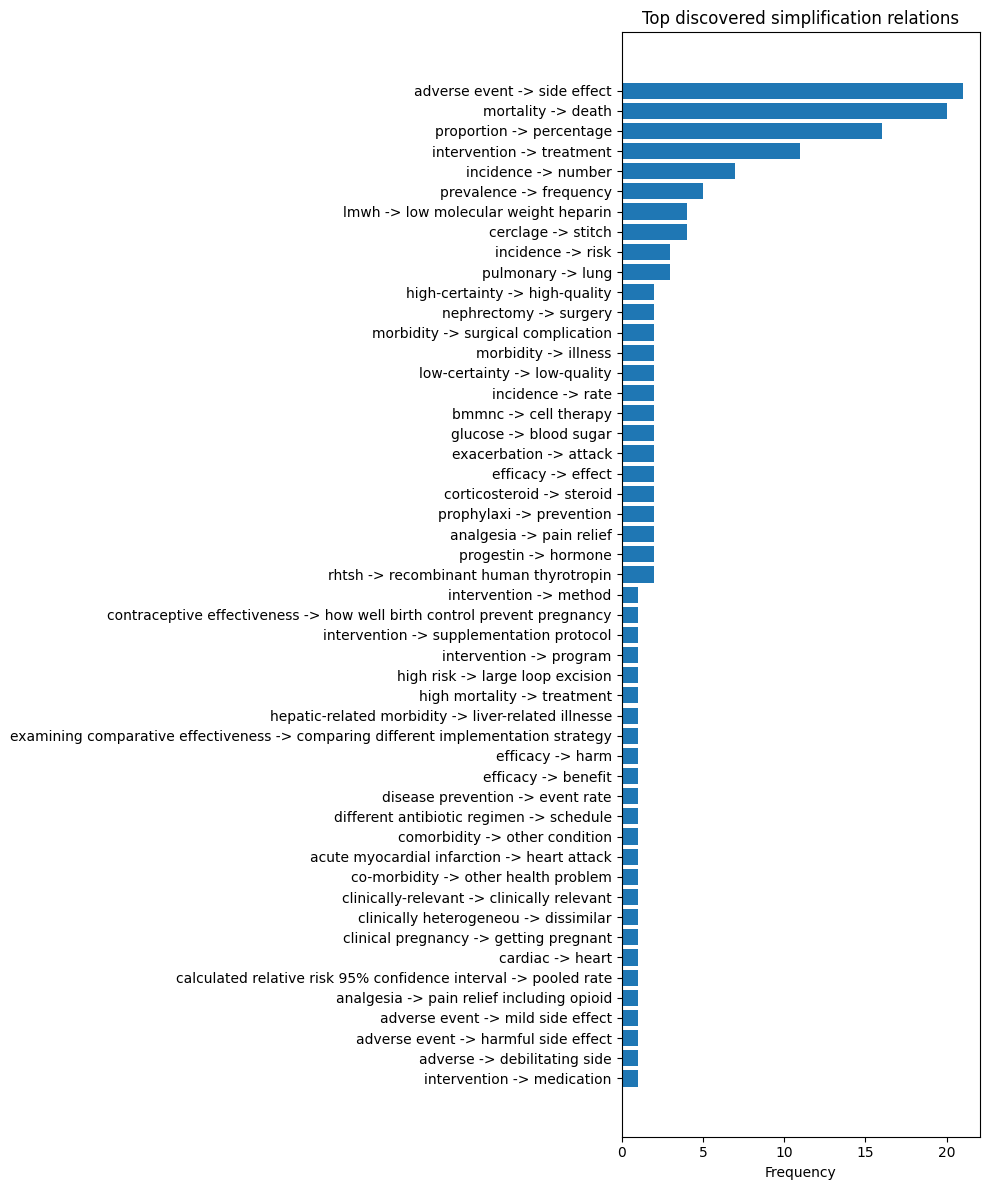

Saved figure: figures/knowledge_graph_top_relations.png


In [18]:
top_50_relations_df = edges_df.head(50)[["source", "target", "frequency", "supporting_sentence_pairs"]].copy()
top_50_relations_df["relation"] = top_50_relations_df["source"] + " -> " + top_50_relations_df["target"]
display(top_50_relations_df[["relation", "frequency", "supporting_sentence_pairs"]])

plt.figure(figsize=(10, 12))
plot_df = top_50_relations_df.sort_values("frequency", ascending=True)
plt.barh(plot_df["relation"], plot_df["frequency"])
plt.xlabel("Frequency")
plt.title("Top discovered simplification relations")
plt.tight_layout()
plt.savefig(TOP_RELATIONS_FIGURE_PATH, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved figure: {TOP_RELATIONS_FIGURE_PATH.relative_to(PROJECT_ROOT)}")

## Build Graph

In [19]:
def validate_induced_graph_tables(nodes: pd.DataFrame, edges: pd.DataFrame) -> None:
    if nodes["node_id"].duplicated().any():
        duplicates = nodes.loc[nodes["node_id"].duplicated(), "node_id"].tolist()
        raise ValueError(f"Duplicate node ids: {duplicates}")
    if edges.duplicated(subset=["source_id", "relation", "target_id"]).any():
        raise ValueError("Duplicate graph edges found after filtering.")
    node_ids = set(nodes["node_id"])
    missing_sources = sorted(set(edges["source_id"]) - node_ids)
    missing_targets = sorted(set(edges["target_id"]) - node_ids)
    if missing_sources:
        raise ValueError(f"Missing source nodes: {missing_sources}")
    if missing_targets:
        raise ValueError(f"Missing target nodes: {missing_targets}")

validate_induced_graph_tables(nodes_df, edges_df)

G = nx.DiGraph()
for row in nodes_df.itertuples(index=False):
    G.add_node(
        row.node_id,
        term=row.term,
        node_type=row.node_type,
        source_frequency=int(row.source_frequency),
        target_frequency=int(row.target_frequency),
    )

for row in edges_df.itertuples(index=False):
    G.add_edge(
        row.source_id,
        row.target_id,
        relation="simplified_as",
        frequency=int(row.frequency),
        supporting_sentence_pairs=int(row.supporting_sentence_pairs),
    )

print(f"Number of nodes: {G.number_of_nodes():,}")
print(f"Number of edges: {G.number_of_edges():,}")
print(f"Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")

degree_df = pd.DataFrame(
    [{"term": G.nodes[node]["term"], "degree": degree} for node, degree in G.degree()]
).sort_values("degree", ascending=False).reset_index(drop=True)
print("Top connected nodes:")
display(degree_df.head(20))

Number of nodes: 142
Number of edges: 95
Average degree: 1.34
Top connected nodes:


,term,degree
0,intervention,18
1,treatment,4
2,proportion,4
3,morbidity,4
4,adverse event,3
5,prevention,3
6,efficacy,3
7,risk,3
8,incidence,3
9,number,3


## Save Graph Files

In [ ]:
nodes_df.to_csv(NODES_PATH, index=False)
edges_df.to_csv(EDGES_PATH, index=False)
raw_edges_df.to_csv(RAW_EDGES_PATH, index=False)
expanded_edges_df.to_csv(EXPANDED_EDGES_PATH, index=False)
raw_edges_df.to_csv(SCORING_REPORT_PATH, index=False)

with GPICKLE_PATH.open("wb") as file:
    pickle.dump(G, file)

nx.write_graphml(G, GRAPHML_PATH)

print(f"Saved nodes: {NODES_PATH.relative_to(PROJECT_ROOT)}")
print(f"Saved edges: {EDGES_PATH.relative_to(PROJECT_ROOT)}")
print(f"Saved raw candidates: {RAW_EDGES_PATH.relative_to(PROJECT_ROOT)}")
print(f"Saved expanded edges: {EXPANDED_EDGES_PATH.relative_to(PROJECT_ROOT)}")
print(f"Saved scoring report: {SCORING_REPORT_PATH.relative_to(PROJECT_ROOT)}")
print(f"Saved graph pickle: {GPICKLE_PATH.relative_to(PROJECT_ROOT)}")
print(f"Saved graphml: {GRAPHML_PATH.relative_to(PROJECT_ROOT)}")



## Helper Functions



In [21]:
def get_term_simplification(term: str, top_k: int = 1) -> str | list[str] | None:
    normalized_term = normalize_phrase(tokenize(term))
    matches = edges_df[edges_df["source"].eq(normalized_term)].sort_values(
        ["frequency", "supporting_sentence_pairs"],
        ascending=[False, False],
    )
    if len(matches) == 0:
        return None
    simplifications = matches["target"].head(top_k).tolist()
    return simplifications[0] if top_k == 1 else simplifications


def phrase_variants(phrase: str) -> set[str]:
    normalized = normalize_phrase(tokenize(phrase))
    variants = {normalized}
    tokens = normalized.split()
    if len(tokens) == 1:
        token = tokens[0]
        variants.add(token + "s")
        if token.endswith("y"):
            variants.add(token[:-1] + "ies")
    return {variant for variant in variants if variant}


def get_sentence_simplifications(sentence: str) -> list[str]:
    normalized_sentence = " ".join(tokenize(sentence))
    found = []
    seen = set()
    for row in edges_df.sort_values("frequency", ascending=False).itertuples(index=False):
        variants = phrase_variants(row.source)
        if any(re.search(rf"(?<![a-z0-9]){re.escape(variant)}(?![a-z0-9])", normalized_sentence) for variant in variants):
            statement = f"{row.source} -> {row.target}"
            if statement not in seen:
                found.append(statement)
                seen.add(statement)
    return found

print("mortality:", get_term_simplification("mortality"))
print("adverse event:", get_term_simplification("adverse events"))
print(get_sentence_simplifications("Mortality and adverse events were reported."))

mortality: death
adverse event: side effect
['mortality -> death', 'mortality -> death after surgery', 'adverse -> debilitating side']


## Inspect Example Sentences

In [22]:
example_sentences = [
    "Mortality and adverse events were reported.",
    "Mortality was reduced.",
    "The confidence interval was wide.",
    "Participants underwent angioplasty after myocardial infarction.",
    "Glucocorticoids reduced airway inflammation.",
]

example_outputs_df = pd.DataFrame(
    [
        {
            "sentence": sentence,
            "discovered_simplifications": get_sentence_simplifications(sentence),
        }
        for sentence in example_sentences
    ]
)
display(example_outputs_df)

,sentence,discovered_simplifications
0,Mortality and adverse events were reported.,"[mortality -> death, mortality -> death after ..."
1,Mortality was reduced.,"[mortality -> death, mortality -> death after ..."
2,The confidence interval was wide.,[]
3,Participants underwent angioplasty after myoca...,[myocardial infarction -> heart attack]
4,Glucocorticoids reduced airway inflammation.,[]
